The following example shows how to train a model. Get a list of training data csv file in the selected folder. Lessons learned so far:
- Training result is very sensitive to normalization. The normalization approach based on mean and variance does not work very well. Still need to manually set mean and variance.
- t-sne plot of adapter trace is an important flag of training result. 
- h net does not have to descent because phi net training strives to make it rise, while h net training itself tries to lower the loss
- Increase the h training frequency to fight against rising h 
- Increase alpha to push domain info to adapter
- Increase number of features to minimize MSE loss.
- ocassional small spike in cross entropy loss is possibly a sign that phi net become further domain invariant and may not be bad.
- at the late stage of training while both mse loss and cross entropy loss converge. May need to train h net every step to refine the optimization direction.
- Do not need to select the model at the end epoch. Select the epoch when the loss is reasonably low and stable. 
- RMS is a good indicator because it matches the least square form of loss function
- When the residual force is small, e.g. training disturbance force compensated by BEMT, disturbance normalization should scale up the label for better learning. 

Existing problem:
- The more classes, the harder to train. The difficulty comes from instability of loss_f and loss_c. alpha is hard to tune.
- t-sne gets worse as epoch grows and the cross entropy loss remains the same. 

In [1]:
import os
import sys
import matplotlib.pyplot as plt

# Get the current directory of the notebook
notebook_dir = os.getcwd()

# Add the parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import training_manager

current_dir = os.getcwd()
training_subfolder = "wind_near_wall_wo_bemt_in_control_train_xz_wind"
# training_subfolder = "wind_near_wall_wo_bemt_in_control_far_from_wall"  # training in no wall condition
# training_subfolder = "nf_training_back2back"
# training_subfolder = "wind_free_space_training_diaml"
# training_subfolder = "wind_free_space_training_in_house_sim_diaml"
# validation_subfolder = "nf_validation_back2back"
validation_subfolder = "wind_near_wall_validation_no_bemt"
# validation_subfolder = "wind_near_wall_validation_no_bemt_sinusoidal"
# validation_subfolder = "wind_free_space_validation_diaml"
# validation_subfolder = "wind_free_space_validation_in_house_sim_diaml"

def generate_data_list(subfolder):
    """
    Generate a list of data files in the specified subfolder.
    """
    folder_path = os.path.join(os.path.dirname(current_dir), "data", "training", subfolder)
    file_names = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

    # Filter out files that do not end with .csv
    file_names = [f for f in file_names if f.endswith('.csv')]
    # add subfolder to the file names
    data_list = [os.path.join(subfolder, f) for f in file_names]
    return data_list

data_list = generate_data_list(training_subfolder)
print("Training Data List:")
for data in data_list:
    print(data)

validation_list = generate_data_list(validation_subfolder)
print("\nValidation Data List:")
for data in validation_list:
    print(data)

path1 = os.path.join(training_subfolder, "input_label_map_disturbance_force_label.yaml")

Training Data List:
wind_near_wall_wo_bemt_in_control_train_xz_wind\test_wind_near_wall_x0_0_y0_0_z0_0_d0_5_train_no_bemt.csv
wind_near_wall_wo_bemt_in_control_train_xz_wind\test_wind_near_wall_x0_0_y0_0_z3_0_d0_5_train_no_bemt.csv
wind_near_wall_wo_bemt_in_control_train_xz_wind\test_wind_near_wall_x0_0_y0_0_z5_0_d0_5_train_no_bemt.csv
wind_near_wall_wo_bemt_in_control_train_xz_wind\test_wind_near_wall_x0_0_y0_0_zn3_0_d0_5_train_no_bemt.csv
wind_near_wall_wo_bemt_in_control_train_xz_wind\test_wind_near_wall_x0_0_y0_0_zn5_0_d0_5_train_no_bemt.csv
wind_near_wall_wo_bemt_in_control_train_xz_wind\test_wind_near_wall_xn1_0_y0_0_z0_0_d0_5_train_no_bemt.csv
wind_near_wall_wo_bemt_in_control_train_xz_wind\test_wind_near_wall_xn1_0_y0_0_z3_0_d0_5_train_no_bemt.csv
wind_near_wall_wo_bemt_in_control_train_xz_wind\test_wind_near_wall_xn1_0_y0_0_z5_0_d0_5_train_no_bemt.csv
wind_near_wall_wo_bemt_in_control_train_xz_wind\test_wind_near_wall_xn1_0_y0_0_zn3_0_d0_5_train_no_bemt.csv
wind_near_wall_wo_b

- Make sure the input_label_map_disturbance_force_label.yaml is in the selected folder. This yaml defines which fields are model inputs and which fields are data labels. 
- Make sure the column_map.yaml is in the selected folder. This yaml maps data fields to the corresponding column in the csv files. This file can be auto-generated by `Simulation\simulation\training_data_user_guide.ipynb`
- If this is the first time to train on this data. The script will normalize the data and save the normalization parameters into a file.

Setting up data factory...
Loading model config from config\pure_diaml_net\data_factory_config.yaml...
Loading normalization params file from
..\data\training\wind_near_wall_wo_bemt_in_control_train_xz_wind\normalization_params.yaml
Using 6001 samples from the dataset for training from source file: wind_near_wall_wo_bemt_in_control_train_xz_wind\test_wind_near_wall_x0_0_y0_0_z0_0_d0_5_train_no_bemt.csv
Using 6001 samples from the dataset for training from source file: wind_near_wall_wo_bemt_in_control_train_xz_wind\test_wind_near_wall_x0_0_y0_0_z3_0_d0_5_train_no_bemt.csv
Using 6001 samples from the dataset for training from source file: wind_near_wall_wo_bemt_in_control_train_xz_wind\test_wind_near_wall_x0_0_y0_0_z5_0_d0_5_train_no_bemt.csv
Using 6001 samples from the dataset for training from source file: wind_near_wall_wo_bemt_in_control_train_xz_wind\test_wind_near_wall_x0_0_y0_0_zn3_0_d0_5_train_no_bemt.csv
Using 6001 samples from the dataset for training from source file: wind_ne

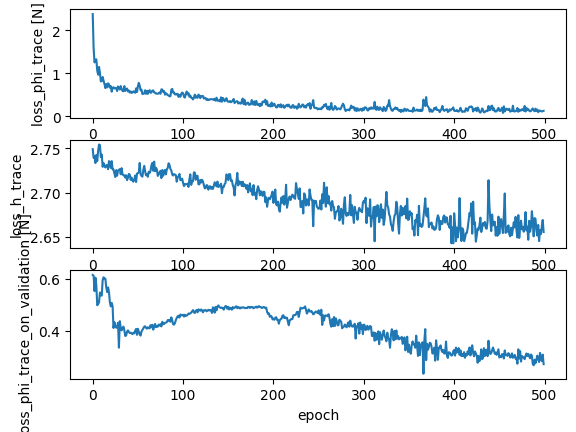

In [2]:
# use the data from previous section to train the model

factory = training_manager.PipelineFactory(training_manager.ModelArchitecture.DAIML)
manager = factory.make_training_pipeline()
manager.set_up(
    training_data_menu=data_list,
    # training_data_menu=data_list[:4],    # use small data list for quick testing
    validation_data_menu=validation_list[-1:],
    input_label_map_file=path1,
    can_inspect_data=False
)
plt.show() 
manager.train()

plt.show()  

Inspect data in the data list.

Plotting t-SNE of a_trace...


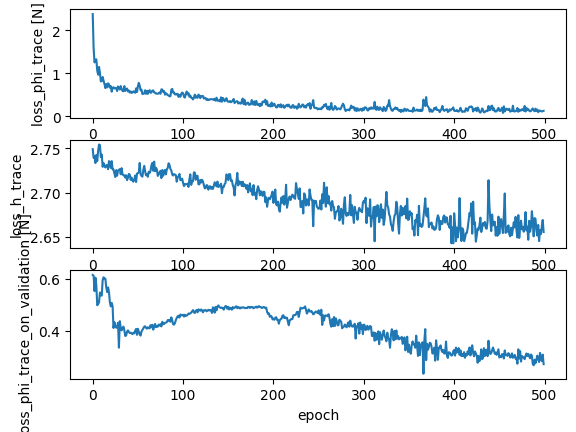

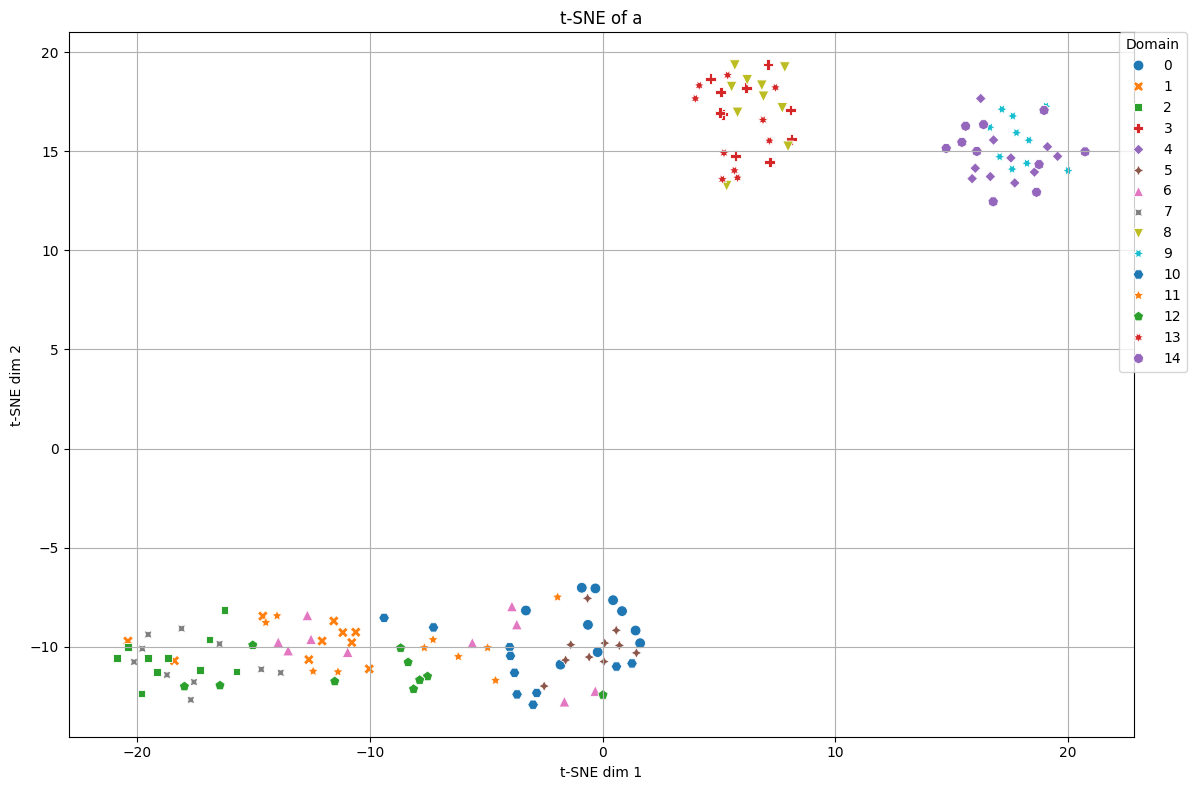

In [3]:
# trainer_instance.inspect_data(data_list[:2])
manager.show_result_only()

After training, we can save the model in the following way.

In [4]:
model_name = training_subfolder
manager.save_model(model_name)

Model saved to model\wind_near_wall_wo_bemt_in_control_train_xz_wind.pth


Test the model using the test set.

test Data List:
wind_near_wall_validation_no_bemt\test_wind_near_wall_x0_0_y0_0_z0_0_d0_5_validation.csv
wind_near_wall_validation_no_bemt\test_wind_near_wall_xn10_0_y0_0_z0_0_d0_5_validation.csv
wind_near_wall_validation_no_bemt\test_wind_near_wall_xn2_0_y0_0_z0_0_d0_5_validation.csv
wind_near_wall_validation_no_bemt\test_wind_near_wall_xn5_0_y0_0_z0_0_d0_5_validation.csv
wind_near_wall_validation_no_bemt\test_wind_near_wall_xn8_0_y0_0_z0_0_d0_5_validation.csv
Setting up data factory...
Loading model config from config\pure_diaml_net\data_factory_config.yaml...
Loading normalization params file from
..\data\training\wind_near_wall_wo_bemt_in_control_train_xz_wind\normalization_params.yaml
Using 4001 samples from the dataset for training from source file: wind_near_wall_validation_no_bemt\test_wind_near_wall_x0_0_y0_0_z0_0_d0_5_validation.csv
Using 4001 samples from the dataset for training from source file: wind_near_wall_validation_no_bemt\test_wind_near_wall_xn10_0_y0_0_z0_0_d0_5_va

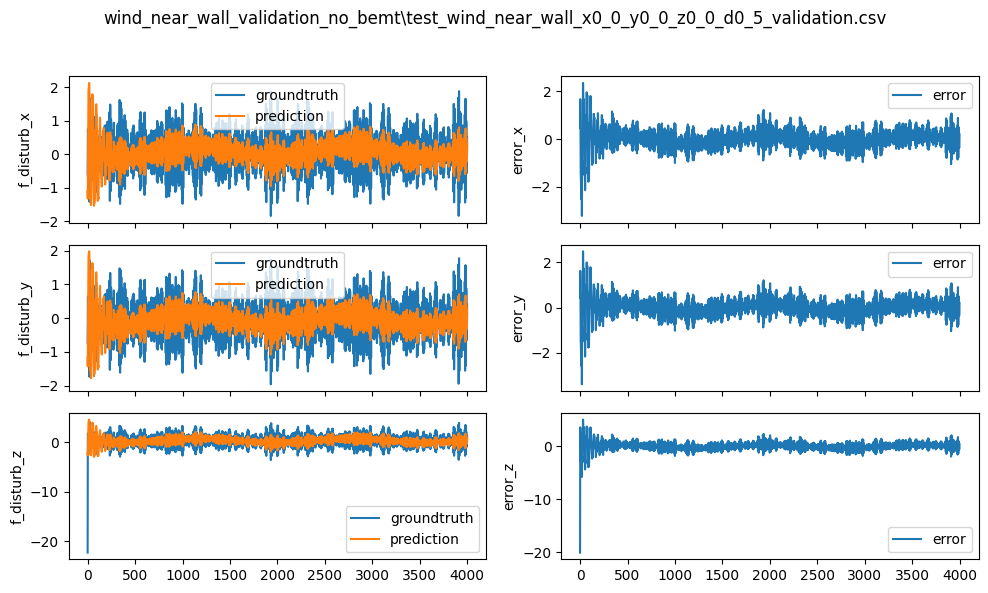

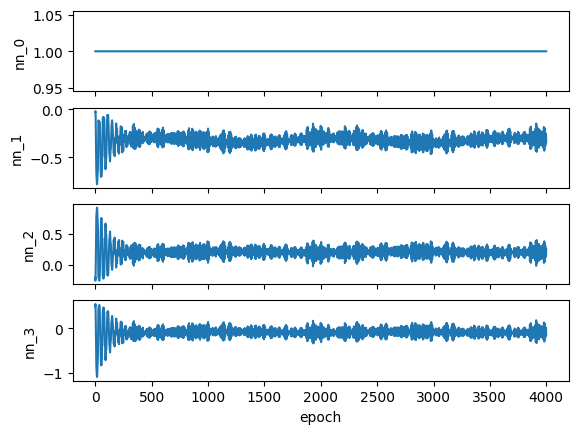

phi_out: tensor([[ 1.0000, -0.0292, -0.2152,  0.5040],
        [ 1.0000, -0.0223, -0.2569,  0.5480],
        [ 1.0000, -0.0422, -0.1882,  0.4630],
        ...,
        [ 1.0000, -0.2750,  0.1424, -0.0117],
        [ 1.0000, -0.3084,  0.1903, -0.0688],
        [ 1.0000, -0.3513,  0.2500, -0.1417]])
a = tensor([[ -5.4027,  -2.3136,  -9.9897],
        [ -4.3631,  -1.3416, -12.4612],
        [ 25.8399,  11.6680,  48.6212],
        [ 18.9394,   6.3623,  37.5743]])


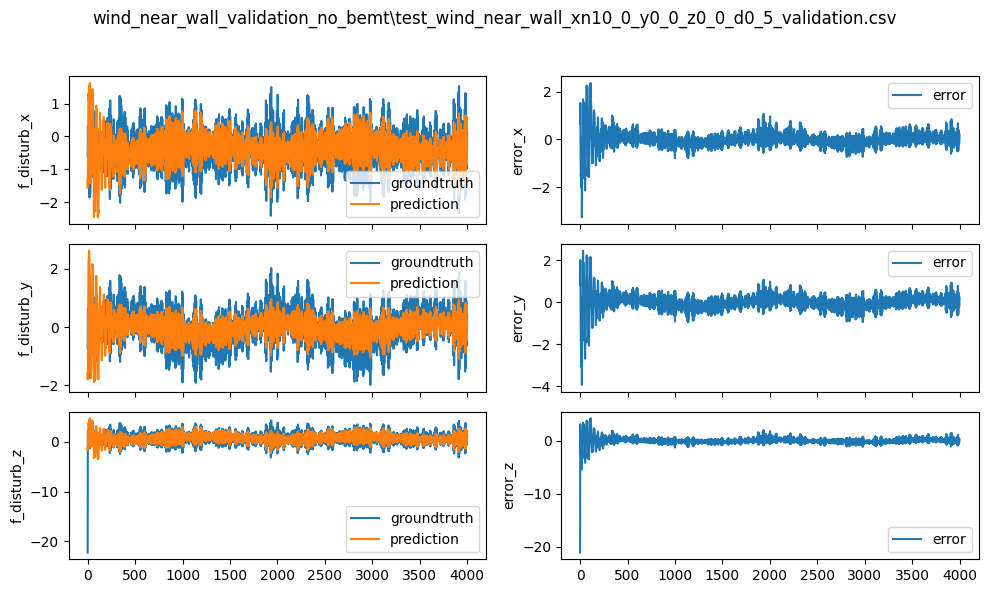

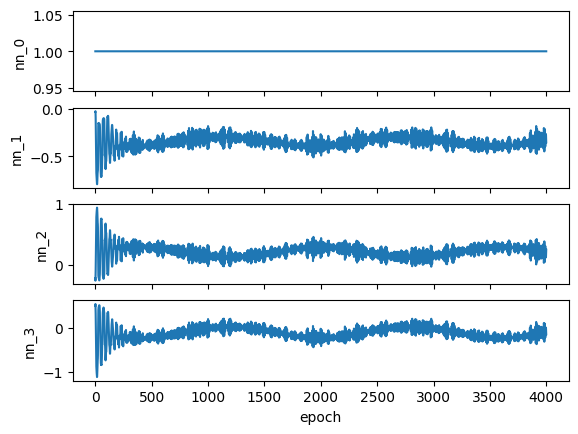

phi_out: tensor([[ 1.0000, -0.0290, -0.2154,  0.5042],
        [ 1.0000, -0.0203, -0.2596,  0.5514],
        [ 1.0000, -0.0391, -0.1929,  0.4696],
        ...,
        [ 1.0000, -0.2684,  0.1470, -0.0124],
        [ 1.0000, -0.3011,  0.1939, -0.0682],
        [ 1.0000, -0.3419,  0.2509, -0.1374]])
a = tensor([[-2.0130, -1.5175, -4.5626],
        [ 0.2530,  2.0023, -3.0257],
        [13.3468, 12.9852, 25.9986],
        [ 7.4547,  6.3011, 15.9840]])


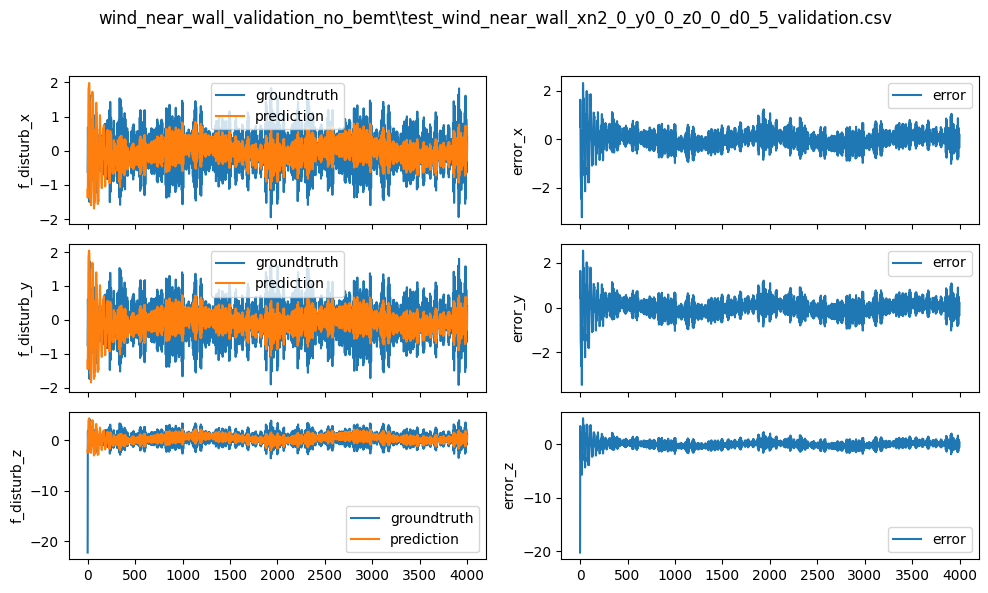

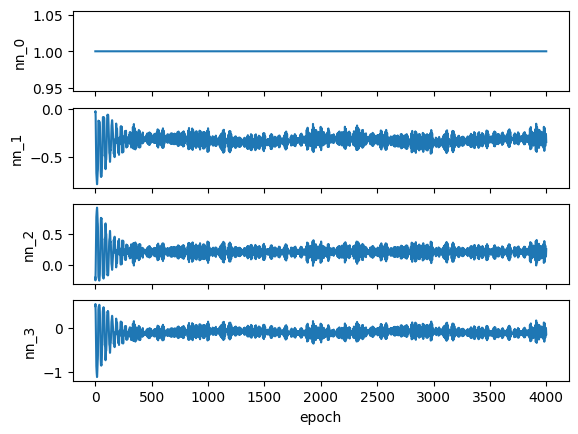

phi_out: tensor([[ 1.0000, -0.0290, -0.2153,  0.5041],
        [ 1.0000, -0.0209, -0.2589,  0.5505],
        [ 1.0000, -0.0399, -0.1917,  0.4679],
        ...,
        [ 1.0000, -0.2719,  0.1491, -0.0166],
        [ 1.0000, -0.3044,  0.1955, -0.0722],
        [ 1.0000, -0.3455,  0.2531, -0.1423]])
a = tensor([[-2.9824, -1.6130, -6.0907],
        [-1.3408,  1.1357, -6.0713],
        [16.2020, 11.8946, 31.5071],
        [10.2917,  5.7195, 21.5302]])


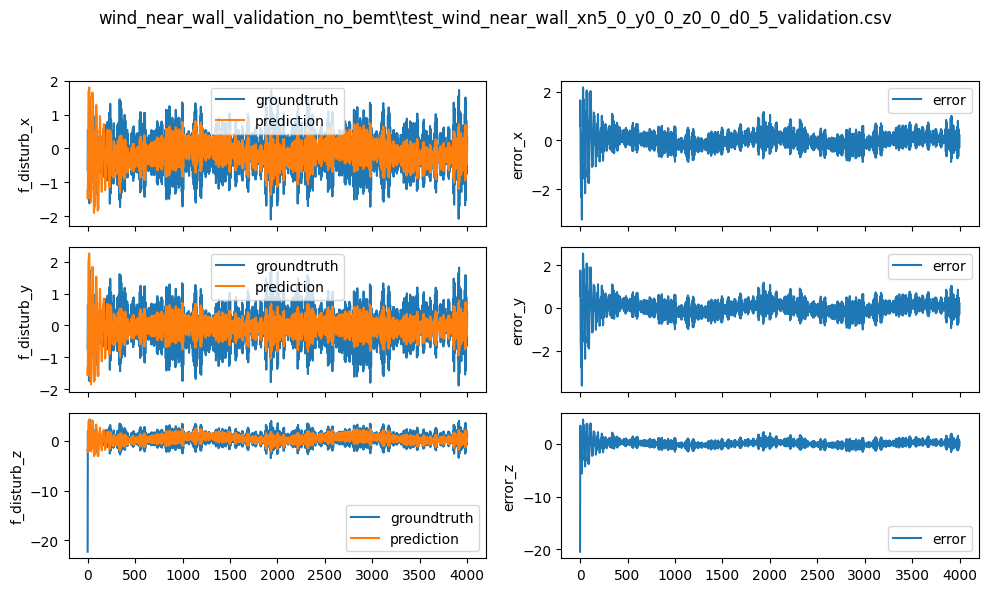

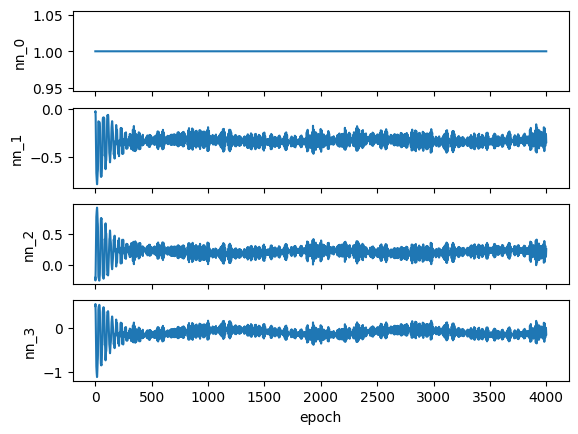

phi_out: tensor([[ 1.0000, -0.0290, -0.2154,  0.5043],
        [ 1.0000, -0.0217, -0.2577,  0.5490],
        [ 1.0000, -0.0414, -0.1892,  0.4644],
        ...,
        [ 1.0000, -0.2720,  0.1431, -0.0112],
        [ 1.0000, -0.3060,  0.1917, -0.0698],
        [ 1.0000, -0.3499,  0.2529, -0.1434]])
a = tensor([[ -4.3882,  -2.0213,  -8.3744],
        [ -3.2812,  -0.3993, -10.1007],
        [ 21.4025,  11.6138,  40.8848],
        [ 15.0742,   6.0172,  30.5181]])


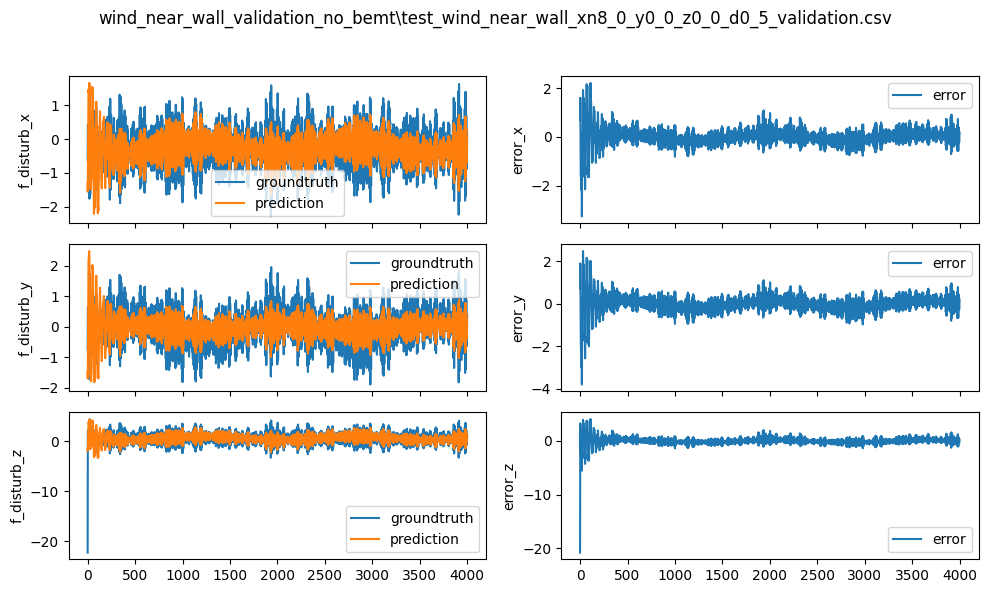

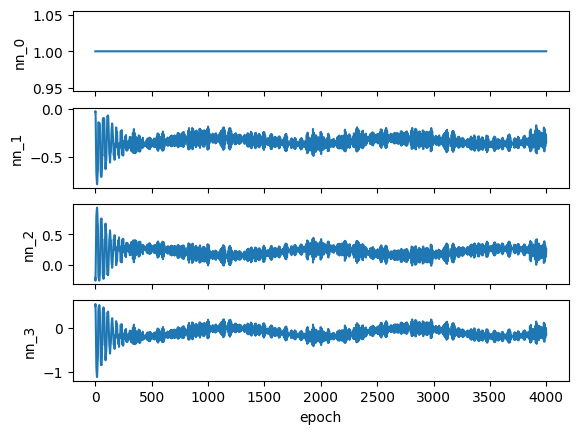

average rms for dim 0: 0.3746171468950322
average rms for dim 1: 0.4040400367468144
average rms for dim 2: 0.7679700109612952


c:\YimingVirtualDDrive\7_workSpace\repo\neural-fly\Simulation\learning\validator.py:71: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


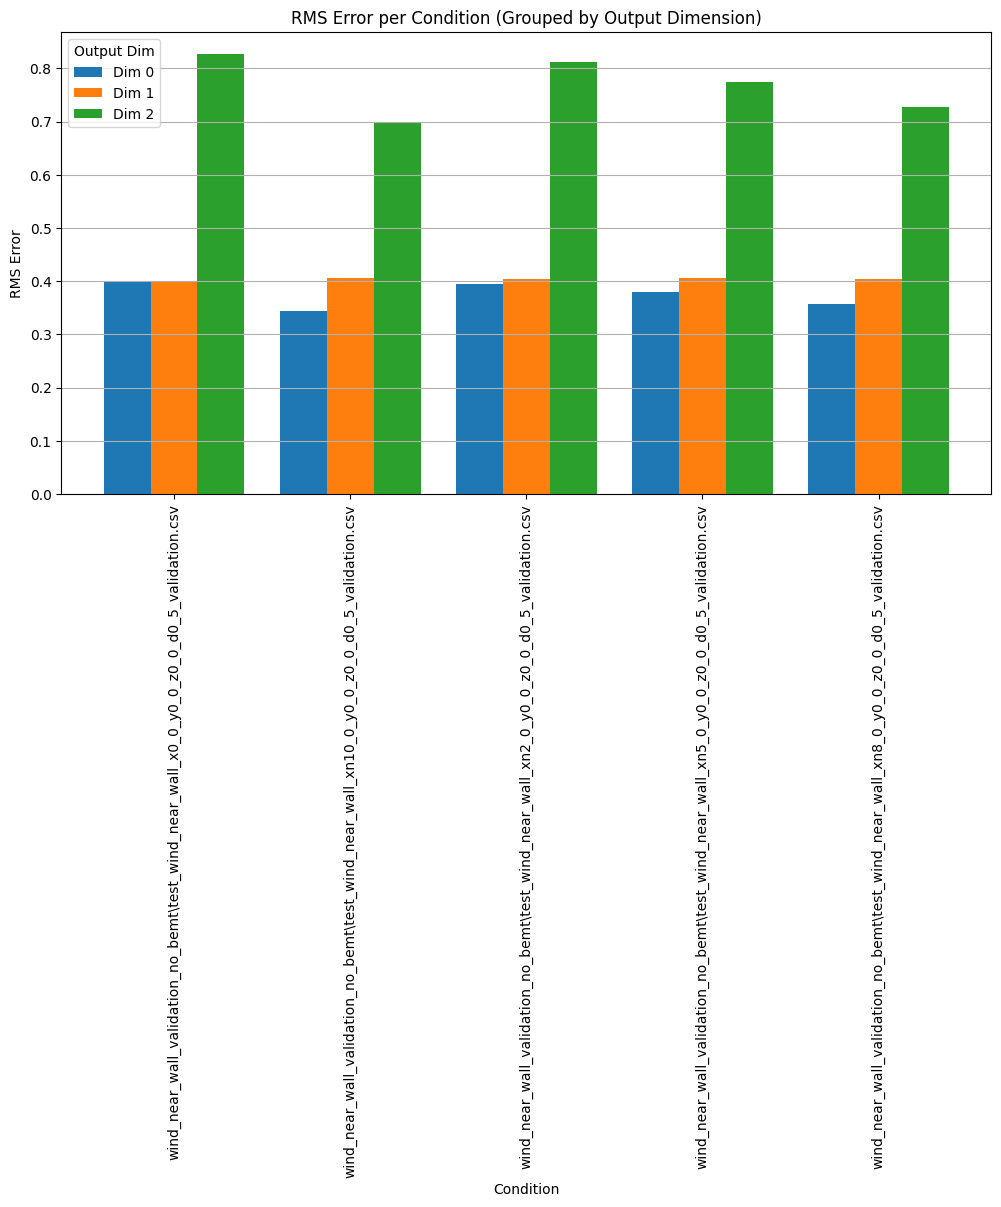

overall average mse after train: 0.8961489171504268 before train: 2.1859526627363715
average mse for dim 0: after train: 0.14078712220405326 before train: 0.3490375072853499
average mse for dim 1: after train: 0.16325614286574444 before train: 0.31446958814992376
average mse for dim 2: after train: 0.592105652080629 before train: 1.522445567301098


c:\YimingVirtualDDrive\7_workSpace\repo\neural-fly\Simulation\learning\validator.py:120: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


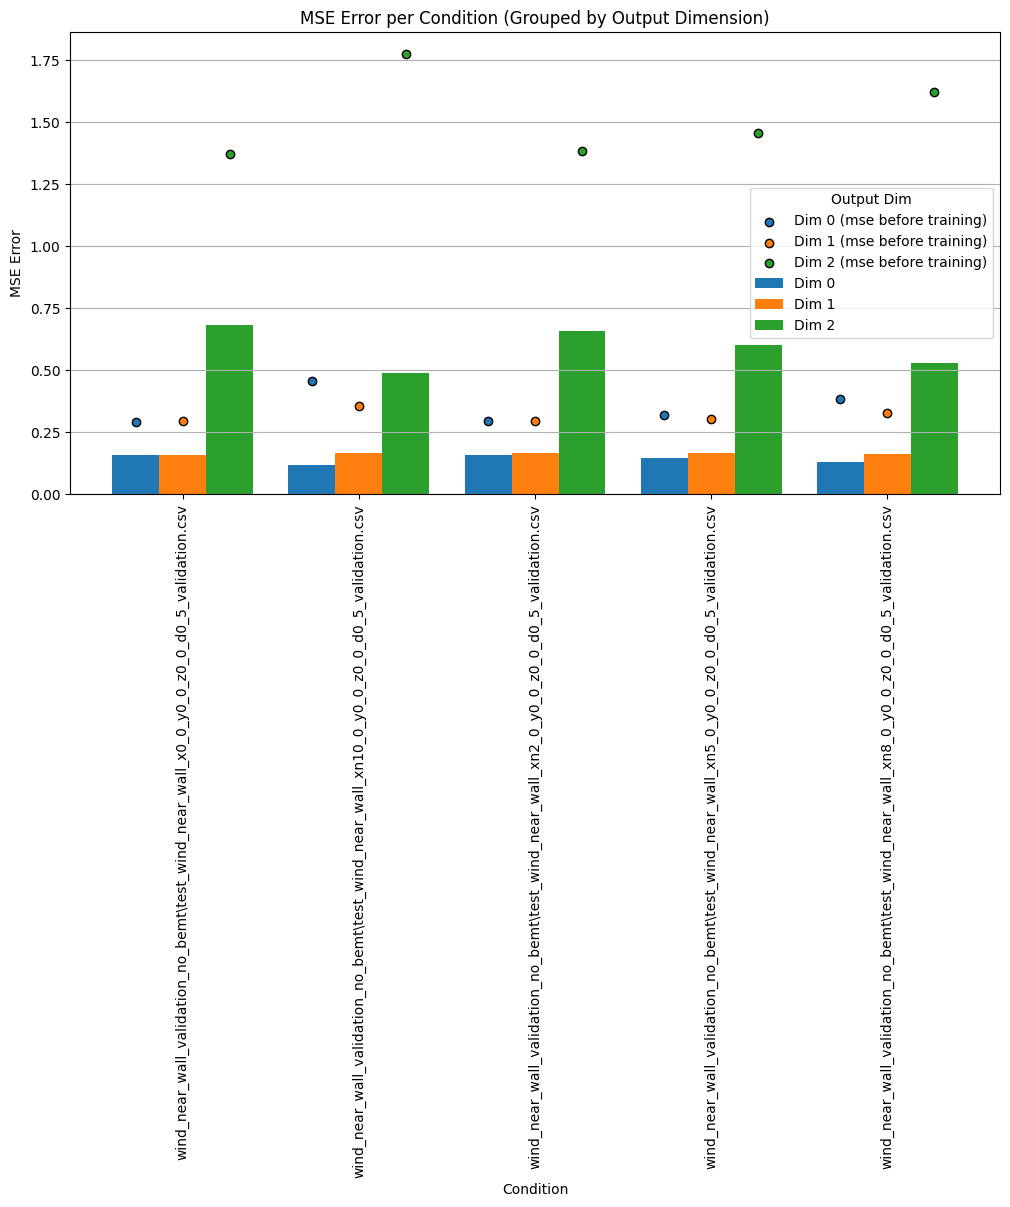

In [5]:
%matplotlib inline
model_name = training_subfolder

subfolder = validation_subfolder
# subfolder = "wind_free_space_validation_diaml"
# subfolder = "nf_validation_back2back"
data_list = generate_data_list(subfolder)
print("test Data List:")
for data in data_list:
    print(data)

# debug
# data_list = data_list[:1]  # use small data list for quick testing

manager = factory.make_test_pipeline()

manager.set_up(
    data_menu=data_list,
    input_label_map_file=path1,
    model_name=model_name
)

# make a new trainer to replicate the above setup, just to allow verify_model to work
manager.test()
plt.show()  
